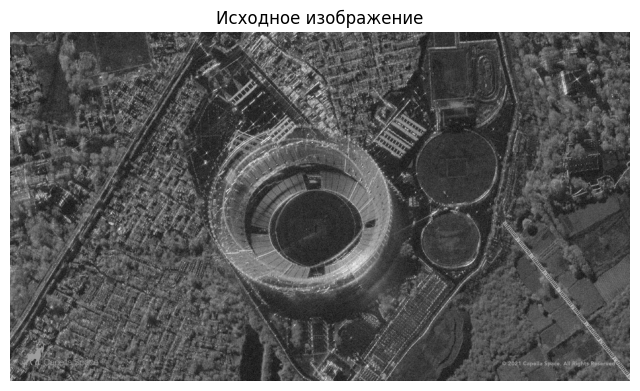

In [17]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Загрузка и подготовка изображения
image = cv2.imread('sar_1.jpg')  # убедись, что файл sar_1.jpg есть в папке
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.show()


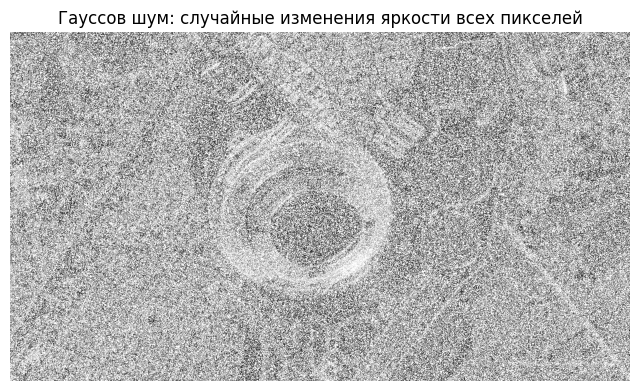

In [20]:
noise_gauss = np.random.normal(0, 30, image_gray.shape).astype(np.uint8)
image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.figure(figsize=(8, 6))
plt.imshow(image_noise_gauss, cmap='gray')
plt.title('Гауссов шум: случайные изменения яркости всех пикселей')
plt.axis('off')
plt.show()

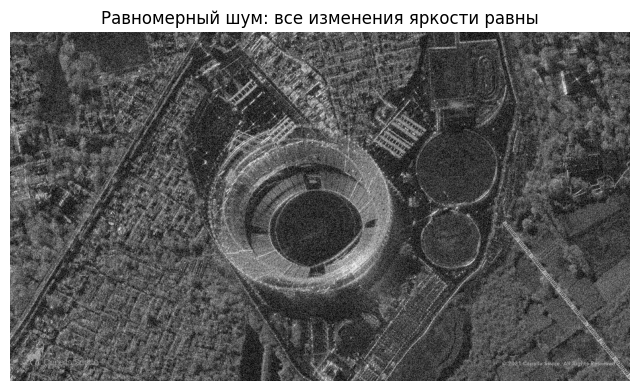

In [35]:
image_uniform = image_gray.copy().astype(np.float32)  # переводим в float для вычислений

# Генерируем шум от -noise_level до +noise_level
noise_level = 40
uniform_noise = np.random.uniform(-noise_level, noise_level, image_gray.shape)

# Добавляем шум и обрезаем значения от 0 до 255
image_uniform = image_uniform + uniform_noise
image_uniform = np.clip(image_uniform, 0, 255).astype(np.uint8)

plt.figure(figsize=(8, 6))
plt.imshow(image_uniform, cmap='gray')
plt.title('Равномерный шум: все изменения яркости равны')
plt.axis('off')
plt.show()


--- Медианный фильтр для гауссова шума ---


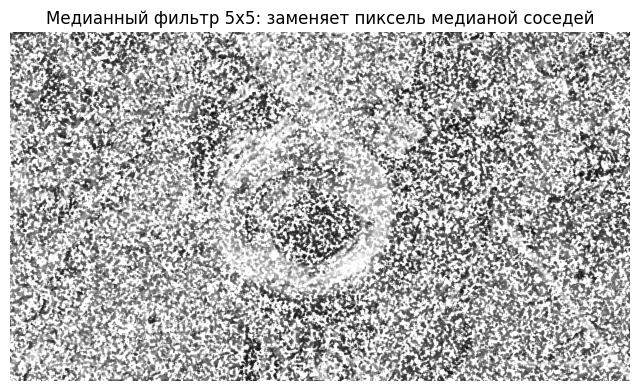

In [22]:
print("\n--- Медианный фильтр для гауссова шума ---")
median_gauss = cv2.medianBlur(image_noise_gauss, 5)
plt.figure(figsize=(8, 6))
plt.imshow(median_gauss, cmap='gray')
plt.title('Медианный фильтр 5x5: заменяет пиксель медианой соседей')
plt.axis('off')
plt.show()

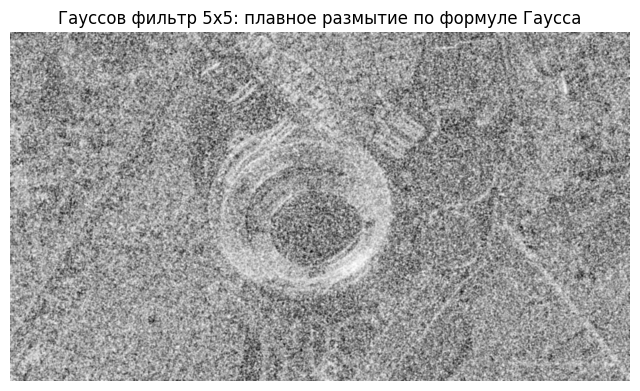

In [23]:
gaussian_gauss = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
plt.figure(figsize=(8, 6))
plt.imshow(gaussian_gauss, cmap='gray')
plt.title('Гауссов фильтр 5x5: плавное размытие по формуле Гаусса')
plt.axis('off')
plt.show()


--- Гауссов фильтр для гауссова шума ---


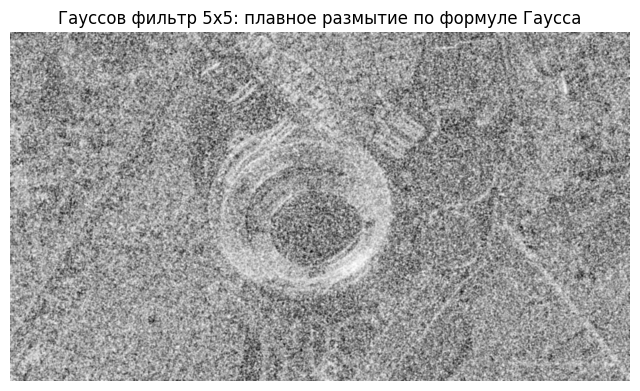

In [24]:
print("\n--- Гауссов фильтр для гауссова шума ---")
gaussian_gauss = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
plt.figure(figsize=(8, 6))
plt.imshow(gaussian_gauss, cmap='gray')
plt.title('Гауссов фильтр 5x5: плавное размытие по формуле Гаусса')
plt.axis('off')
plt.show()

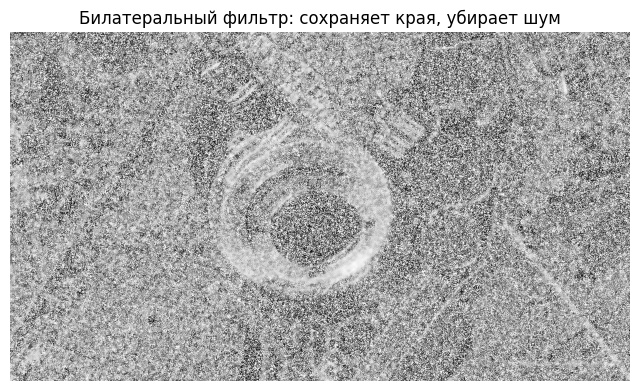

In [25]:
bilateral_gauss = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
plt.figure(figsize=(8, 6))
plt.imshow(bilateral_gauss, cmap='gray')
plt.title('Билатеральный фильтр: сохраняет края, убирает шум')
plt.axis('off')
plt.show()


--- Билатеральный фильтр для гауссова шума ---


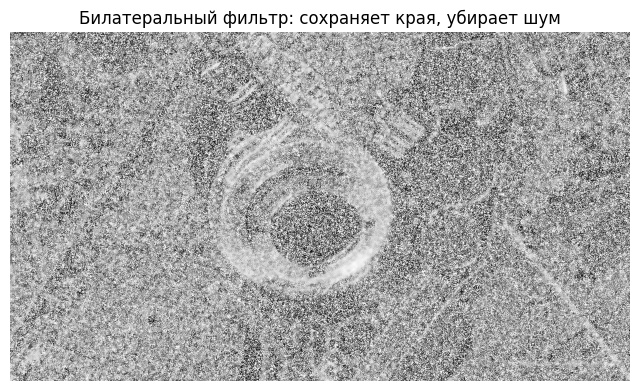

In [26]:
print("\n--- Билатеральный фильтр для гауссова шума ---")
bilateral_gauss = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
plt.figure(figsize=(8, 6))
plt.imshow(bilateral_gauss, cmap='gray')
plt.title('Билатеральный фильтр: сохраняет края, убирает шум')
plt.axis('off')
plt.show()

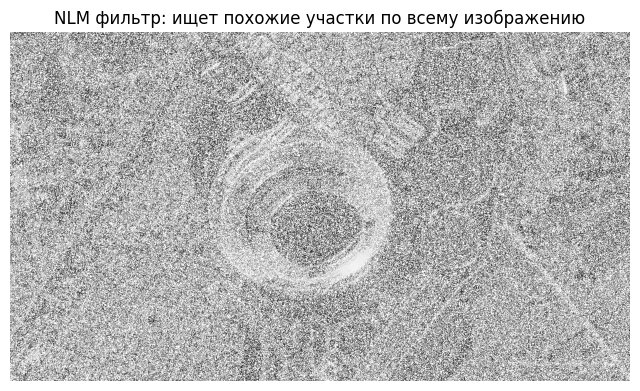

In [27]:
nlm_gauss = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)
plt.figure(figsize=(8, 6))
plt.imshow(nlm_gauss, cmap='gray')
plt.title('NLM фильтр: ищет похожие участки по всему изображению')
plt.axis('off')
plt.show()

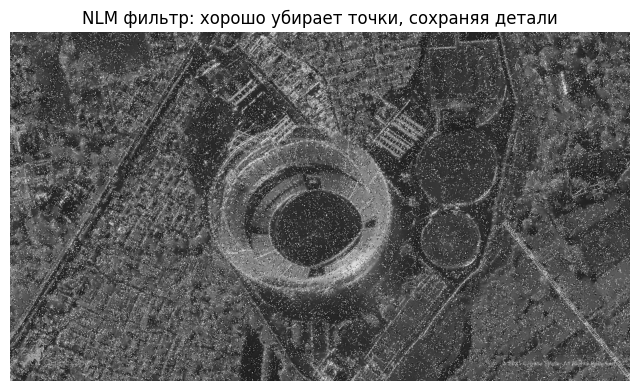

In [56]:
nlm_sp = cv2.fastNlMeansDenoising(image_sp, h=20)
plt.figure(figsize=(8, 6))
plt.imshow(nlm_sp, cmap='gray')
plt.title('NLM фильтр: хорошо убирает точки, сохраняя детали')
plt.axis('off')
plt.show()


--- Медианный фильтр для равномерного шума ---


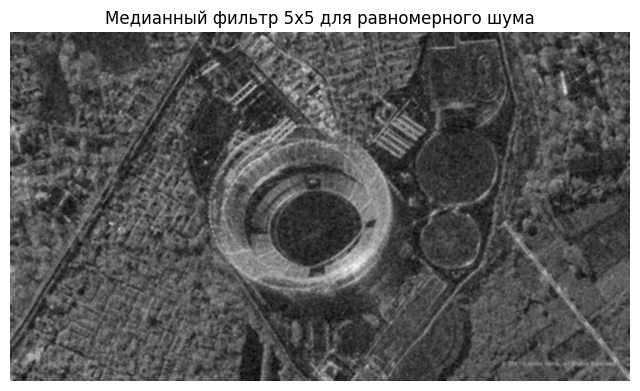

Медианный фильтр применен


In [30]:
# ФИЛЬТРАЦИЯ РАВНОМЕРНОГО ШУМА

median_uniform = cv2.medianBlur(image_uniform, 5)
plt.figure(figsize=(8, 6))
plt.imshow(median_uniform, cmap='gray')
plt.title('Медианный фильтр 5x5 для равномерного шума')
plt.axis('off')
plt.show()
print("Медианный фильтр применен")

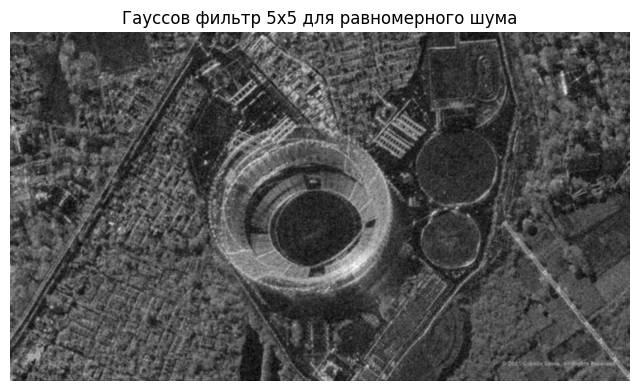

Гауссов фильтр применен


In [31]:
gaussian_uniform = cv2.GaussianBlur(image_uniform, (5, 5), 0)
plt.figure(figsize=(8, 6))
plt.imshow(gaussian_uniform, cmap='gray')
plt.title('Гауссов фильтр 5x5 для равномерного шума')
plt.axis('off')
plt.show()
print("Гауссов фильтр применен")


--- Билатеральный фильтр для равномерного шума ---


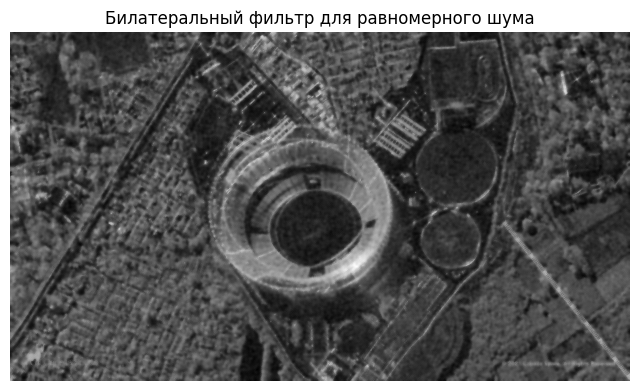

In [32]:

bilateral_uniform = cv2.bilateralFilter(image_uniform, 9, 75, 75)
plt.figure(figsize=(8, 6))
plt.imshow(bilateral_uniform, cmap='gray')
plt.title('Билатеральный фильтр для равномерного шума')
plt.axis('off')
plt.show()

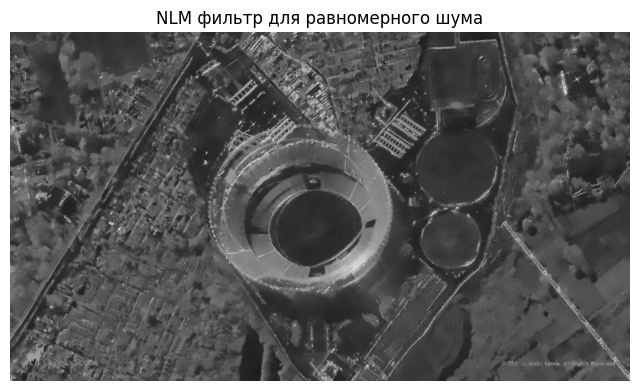

In [33]:
nlm_uniform = cv2.fastNlMeansDenoising(image_uniform, h=20)
plt.figure(figsize=(8, 6))
plt.imshow(nlm_uniform, cmap='gray')
plt.title('NLM фильтр для равномерного шума')
plt.axis('off')
plt.show()

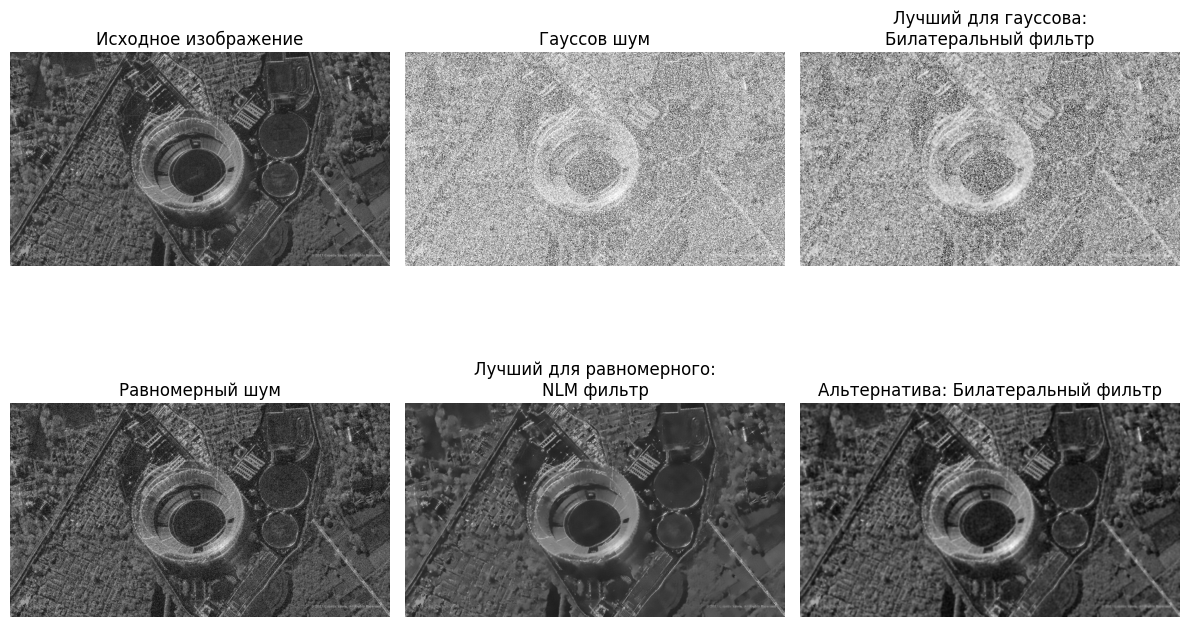

In [34]:
# ИТОГИ И СРАВНЕНИЕ
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(image_noise_gauss, cmap='gray')
plt.title('Гауссов шум')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(bilateral_gauss, cmap='gray')
plt.title('Лучший для гауссова:\nБилатеральный фильтр')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(image_uniform, cmap='gray')
plt.title('Равномерный шум')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(nlm_uniform, cmap='gray')
plt.title('Лучший для равномерного:\nNLM фильтр')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(bilateral_uniform, cmap='gray')
plt.title('Альтернатива: Билатеральный фильтр')
plt.axis('off')

plt.tight_layout()
plt.show()